In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import configparser
import ast
import arviz as az
from pathlib import Path

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / "results"
TRACE_DIR = BASE_DIR / "results/trace"
PPC_DIR = BASE_DIR / "results/ppc"
PLOT_DIR = RESULTS_DIR / "plots/"

os.makedirs(PLOT_DIR, exist_ok=True)

In [27]:
with open(TRACE_DIR / "final_trace_owner.pkl", "rb") as f:
    fin_tr_owner = pickle.load(f)
    
with open(TRACE_DIR / "final_trace_agent.pkl", "rb") as f:
    fin_tr_agent = pickle.load(f)

In [28]:
log_z_owner = fin_tr_owner.sample_stats.log_marginal_likelihood.mean().item()
log_z_agent = fin_tr_agent.sample_stats.log_marginal_likelihood.mean().item()

# 3. Bayes Factor Computation
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- BATCH RESULTS ---")
print(f"Log Z (Owner Model): {log_z_owner:.4f}")
print(f"Log Z (Agent Model): {log_z_agent:.4f}")
print(f"Bayes Factor:  {BF:.4e}")

if BF > 1000:
    print("Conclusion: Decisive Evidence for the AGENT model.")
elif BF > 10:
    print("Conclusion: Strong Evidence for the AGENT model.")
elif BF > 1:
    print("Conclusion: Moderate Evidence for the AGENT model.")
elif BF > 0.1:
    print("Conclusion: Moderate Evidence for the OWNER model.")
elif BF > 0.01:
    print("Conclusion: Strong Evidence for the OWNER model.")
else:
    print("Conclusion: Decisive Evidence for the OWNER model.")


--- BATCH RESULTS ---
Log Z (Owner Model): -4.7076
Log Z (Agent Model): -2.2944
Bayes Factor:  1.1169e+01
Conclusion: Strong Evidence for the AGENT model.


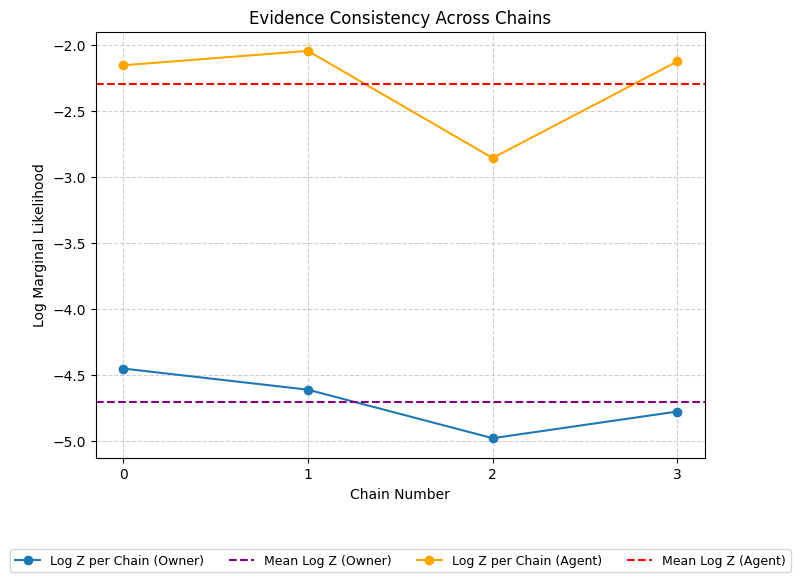

In [30]:
# Access the log_marginal_likelihood per chain
# This shows if all chains reached roughly the same conclusion
log_z_per_chain_owner = fin_tr_owner.sample_stats.log_marginal_likelihood.values[:,-1]
log_z_per_chain_agent = fin_tr_agent.sample_stats.log_marginal_likelihood.values[:,-1]

plt.figure(figsize=(8, 6))
plt.plot(log_z_per_chain_owner, 'o-', label='Log Z per Chain (Owner)')
plt.axhline(log_z_per_chain_owner.mean(), color='purple', linestyle='--', label='Mean Log Z (Owner)')
plt.plot(log_z_per_chain_agent, 'o-', color='orange', label='Log Z per Chain (Agent)')
plt.axhline(log_z_per_chain_agent.mean(), color='r', linestyle='--', label='Mean Log Z (Agent)')

plt.xlabel('Chain Number')
plt.ylabel('Log Marginal Likelihood')
plt.title('Evidence Consistency Across Chains')
plt.xticks([0, 1, 2, 3])
plt.grid(True, linestyle='--', alpha=0.6)

# Move legend below the plot, center it, and set to 4 columns
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=9, ncol=4, frameon=True)

# Use tight_layout or subplots_adjust to ensure the legend isn't cut off
plt.tight_layout() 
plt.savefig(PLOT_DIR / "Evidence Consistency Across Chains.png")
plt.show()

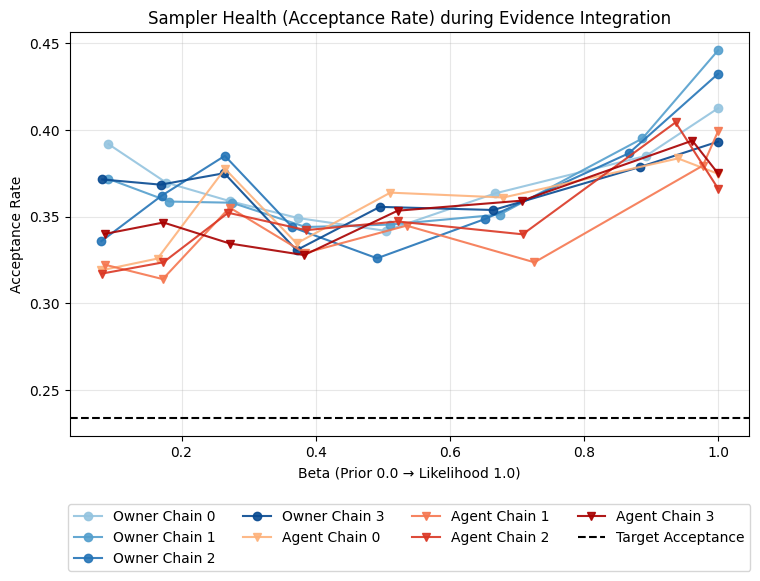

In [31]:
# Accessing the available variables from your KeyError list
accept_rates_owner = fin_tr_owner.sample_stats["accept_rate"].values
betas_owner = fin_tr_owner.sample_stats["beta"].values
accept_rates_agent = fin_tr_agent.sample_stats["accept_rate"].values
betas_agent = fin_tr_agent.sample_stats["beta"].values

plt.figure(figsize=(8, 6))

# Create color gradients
owner_colors = plt.cm.Blues(np.linspace(0.4, 0.9, accept_rates_owner.shape[0]))
agent_colors = plt.cm.OrRd(np.linspace(0.4, 0.9, accept_rates_agent.shape[0]))

# Owner chains (blue shades)
for i in range(accept_rates_owner.shape[0]):
    plt.plot(
        betas_owner[i],
        accept_rates_owner[i],
        'o-',
        color=owner_colors[i],
        alpha=0.9,
        label=f'Owner Chain {i}'
    )

# Agent chains (orange/red shades)
for i in range(accept_rates_agent.shape[0]):
    plt.plot(
        betas_agent[i],
        accept_rates_agent[i],
        'v-',
        color=agent_colors[i],
        alpha=0.9,
        label=f'Agent Chain {i}'
    )

plt.axhline(y=0.234, color='k', linestyle='--', label='Target Acceptance')
plt.xlabel('Beta (Prior 0.0 → Likelihood 1.0)')
plt.ylabel('Acceptance Rate')
plt.title('Sampler Health (Acceptance Rate) during Evidence Integration')
plt.grid(True, alpha=0.3)
plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=4, 
    frameon=True
)
plt.tight_layout()
plt.savefig(PLOT_DIR / "Acceptance Rate.png")
plt.show()

In [32]:
with open(PPC_DIR / "ppc_owner.pkl", "rb") as f:
    ppc_owner = pickle.load(f)
    
with open(PPC_DIR / "ppc_agent.pkl", "rb") as f:
    ppc_agent = pickle.load(f)

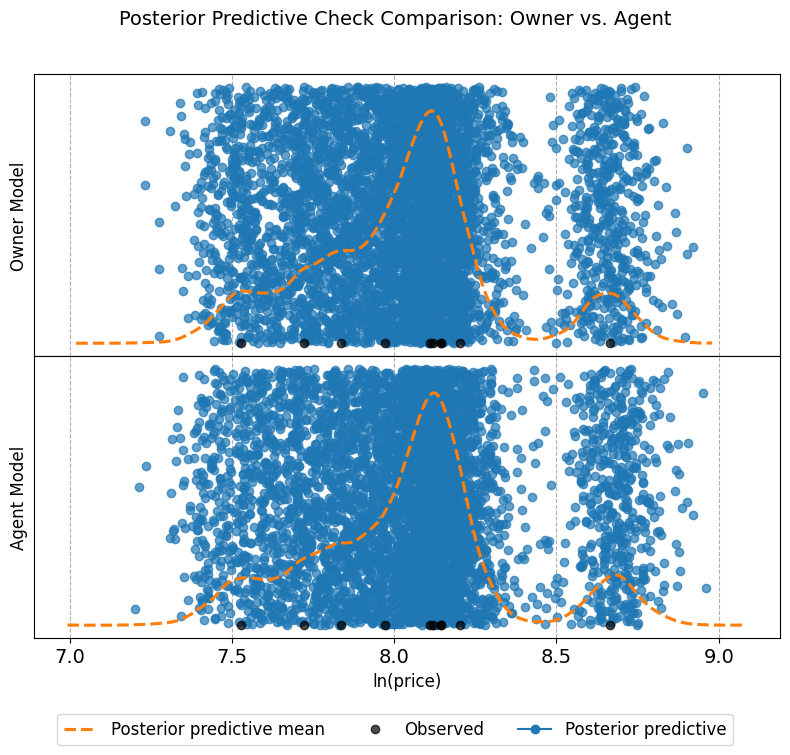

In [33]:
# Create subplots with shared x-axis
fig, (ax_owner, ax_agent) = plt.subplots(nrows=2, ncols=1, figsize=(8, 8), sharex=True)

# Plot Owner Model PPC (Top)
az.plot_ppc(ppc_owner, kind="scatter", num_pp_samples=500, ax=ax_owner, legend=False)
ax_owner.set_ylabel("Owner Model", fontsize=12)
ax_owner.grid(True, linestyle='--', alpha=1)

# Plot Agent Model PPC (Bottom)
az.plot_ppc(ppc_agent, kind="scatter", num_pp_samples=500, ax=ax_agent, legend=False)
ax_agent.set_ylabel("Agent Model", fontsize=12)
ax_agent.grid(True, linestyle='--', alpha=1)

# Set main title
fig.suptitle("Posterior Predictive Check Comparison: Owner vs. Agent", fontsize=14, y=0.95)

# Add X-axis label to bottom plot
ax_agent.set_xlabel("ln(price)", fontsize=12)

# Create the shared 3-column legend
handles, labels = ax_owner.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    fontsize=12,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02), 
    ncol=3, 
    frameon=True
)

# CRITICAL STEP: Adjust layout first, THEN remove hspace
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.subplots_adjust(hspace=0) 
plt.savefig(PLOT_DIR / "PPC.png")
plt.show()

In [34]:
def load_config(filename=BASE_DIR / "app/config.ini"):
    """Parses the config.ini file into a usable dictionary."""
    # Use inline_comment_prefixes to ignore everything after '#'
    config_parser = configparser.ConfigParser(inline_comment_prefixes=('#',))
    config_parser.read(filename)

    c = {}

    # PRICE ARGUMENTS Section
    price = config_parser['PRICE_ARGUMENTS']
    c['noise_scale'] = float(price['noise_scale'])
    c['base'] = float(price['base'])
    c['room_coeff'] = float(price['room_coeff'])
    c['distance_coeff'] = float(price['distance_coeff'])
    c['underground_fee'] = float(price['underground_fee'])
    c['house_fee'] = float(price['house_fee'])
    c['garden_fee'] = float(price['garden_fee'])
    c['terrace_fee'] = float(price['terrace_fee'])
    c['balcony_fee'] = float(price['balcony_fee'])
    c['agent_premium'] = float(price['agent_premium'])
    c['market_vol'] = float(price['market_vol'])
    # Vol Scales
    c['vol_scales'] = {
        "intercept": float(price['base_vol_scale']),
        "beta_room": float(price['room_coeff_vol_scale']),
        "beta_dist": float(price['distance_coeff_vol_scale']),
        "beta_under": float(price['underground_fee_vol_scale']),
        "beta_house": float(price['house_fee_vol_scale']),
        "beta_garden": float(price['garden_fee_vol_scale']),
        "beta_terrace": float(price['terrace_fee_vol_scale']),
        "beta_balcony": float(price['balcony_fee_vol_scale']),
        "premium": float(price['agent_premium_vol_scale'])
    }
    
    # ANALYSIS Section
    # Note: Use exact string 'DATA GENERATION' as per your .ini file
    da = config_parser['ANALYSIS']
    # Define the master list of all possible price arguments considered by fixed_price_args and known_market_price_args.
    all_possible = [
        "base", "room_coeff", "distance_coeff", "garden_fee", 
        "terrace_fee", "balcony_fee", "underground_fee", "house_fee"
    ]
    # Parse the lists from the config (using json.loads to convert string representation to Python list)
    c['fixed_price_args'] = ast.literal_eval(da['fixed_price_args'])
    c['known_market_price_args'] = ast.literal_eval(da['known_market_price_args'])
    accounted_for = set(c['fixed_price_args']) | set(c['known_market_price_args'])
    c['unknown_price_args'] = [arg for arg in all_possible if arg not in accounted_for]

    return c

config = load_config()

In [35]:
# Market-Level Means ---
mt_mu_inter        = config['base']
mt_mu_beta_room    = config['room_coeff']
mt_mu_beta_dist    = config['distance_coeff']
mt_mu_beta_under   = config['underground_fee']
mt_mu_beta_house   = config['house_fee']
mt_mu_beta_garden  = config['garden_fee']
mt_mu_beta_terrace = config['terrace_fee']
mt_mu_beta_balcony = config['balcony_fee']
mt_mu_premium      = config['agent_premium']
# Market-Level Sigmas ---
mv = config['market_vol']
vs = config['vol_scales']
mt_sig_inter        = mv * vs["intercept"]
mt_sig_beta_room    = mv * vs["beta_room"]
mt_sig_beta_dist    = mv * vs["beta_dist"]
mt_sig_beta_under   = mv * vs["beta_under"]
mt_sig_beta_house   = mv * vs["beta_house"]
mt_sig_beta_garden  = mv * vs["beta_garden"]
mt_sig_beta_terrace = mv * vs["beta_terrace"]
mt_sig_beta_balcony = mv * vs["beta_balcony"]
mt_sig_premium      = mv * vs["premium"]

# Mapping internal argument keys to their respective Market Truth (mt) constants
market_truth_map = {
    "base": (mt_mu_inter, mt_sig_inter),
    "room_coeff": (mt_mu_beta_room, mt_sig_beta_room),
    "distance_coeff": (mt_mu_beta_dist, mt_sig_beta_dist),
    "underground_fee": (mt_mu_beta_under, mt_sig_beta_under),
    "house_fee": (mt_mu_beta_house, mt_sig_beta_house),
    "garden_fee": (mt_mu_beta_garden, mt_sig_beta_garden),
    "terrace_fee": (mt_mu_beta_terrace, mt_sig_beta_terrace),
    "balcony_fee": (mt_mu_beta_balcony, mt_sig_beta_balcony),
    "prem": (mt_mu_premium, mt_sig_premium)
}

In [36]:
plot_vars = config['unknown_price_args'] + ['prem']

# Generate a single list with both prefixes for every variable
all_plot_vars = [f"{prefix}{var}" for var in plot_vars for prefix in ("mu_m_", "sig_m_")]

print(all_plot_vars)

['mu_m_room_coeff', 'sig_m_room_coeff', 'mu_m_distance_coeff', 'sig_m_distance_coeff', 'mu_m_prem', 'sig_m_prem']


In [37]:
market_parameters_truth = {}

for plot_var in plot_vars:
    mu_m, sig_m = market_truth_map[plot_var]

    market_parameters_truth[f"mu_m_{plot_var}"] = mu_m
    market_parameters_truth[f"sig_m_{plot_var}"] = sig_m

print(market_parameters_truth)

{'mu_m_room_coeff': 0.15, 'sig_m_room_coeff': 0.045, 'mu_m_distance_coeff': -0.05, 'sig_m_distance_coeff': 0.03, 'mu_m_prem': 0.15, 'sig_m_prem': 0.041999999999999996}


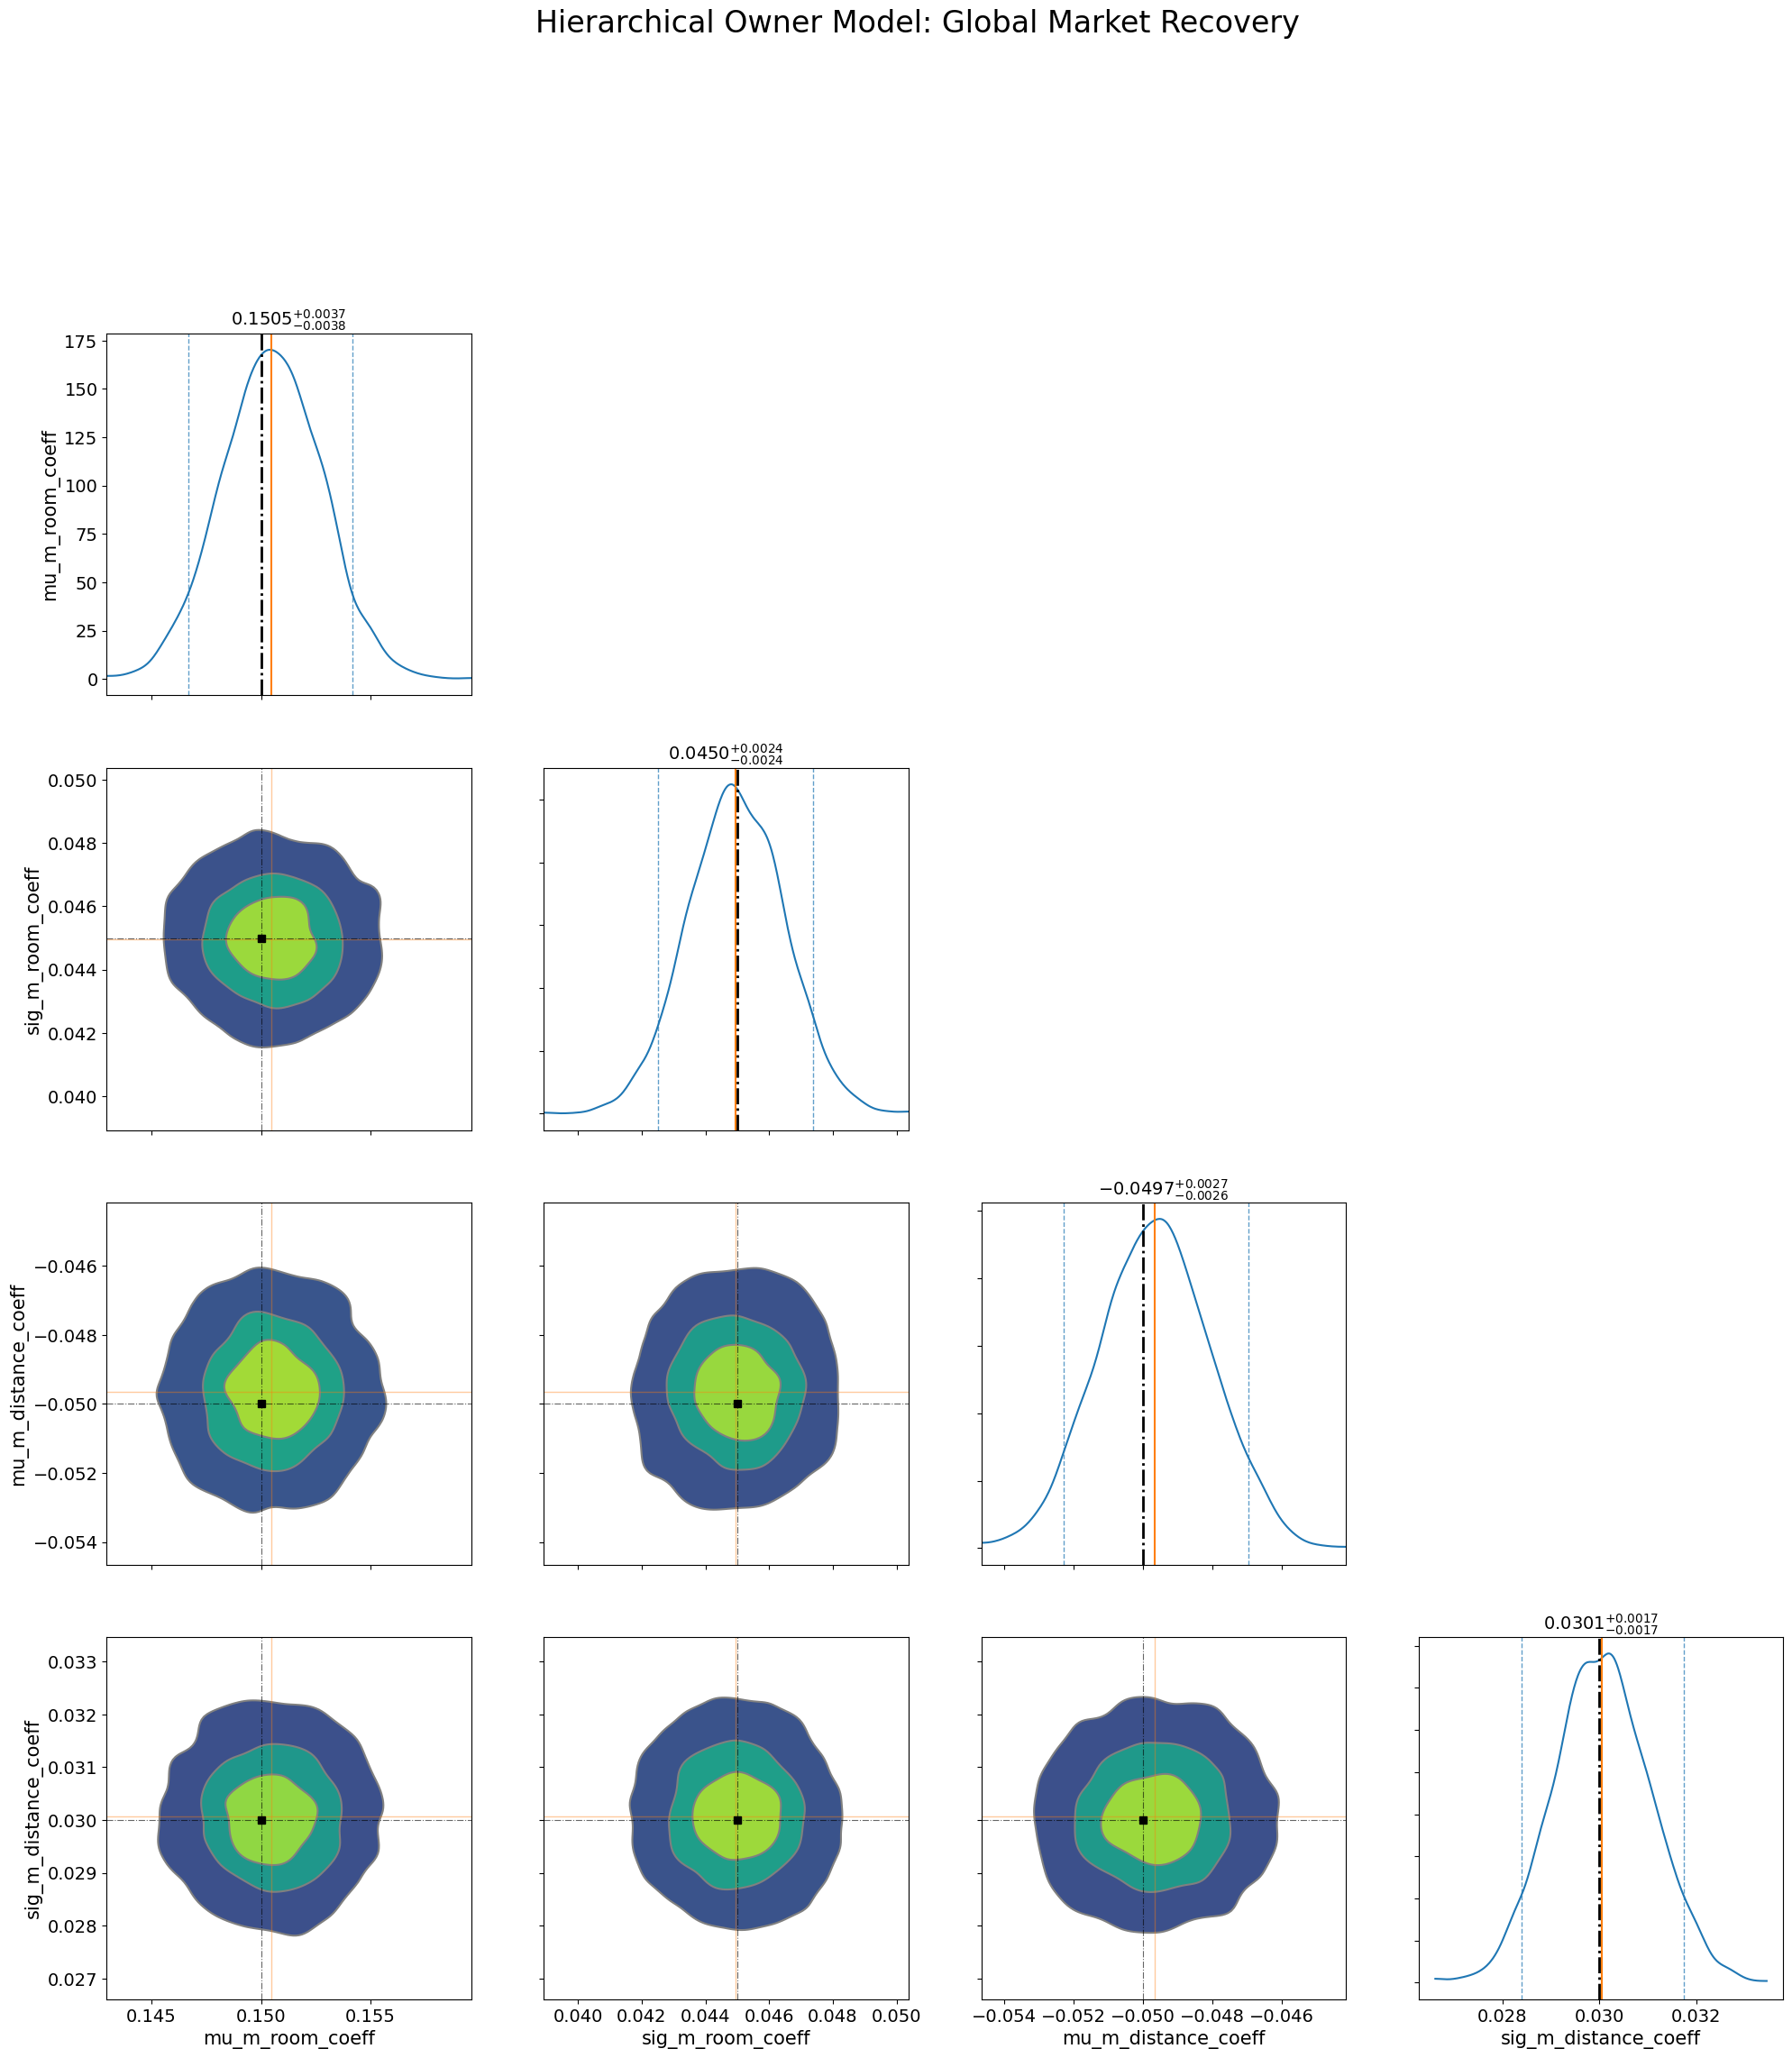

In [38]:
### Make corner plot of global parameters

# --- PLOTTING ---
axes = az.plot_pair(
    fin_tr_owner,
    var_names=all_plot_vars[:-2],
    kind='kde',
    marginals=True,
    figsize=(24, 24),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

all_x_labels = [ax.get_xlabel() for ax in axes[-1, :]]
all_y_labels = [ax.get_ylabel() for ax in axes[:, 0]]

for i in range(len(all_y_labels)):
    for j in range(len(all_x_labels)):
        ax = axes[i, j]
        if ax is None: continue
        
        row_label = all_y_labels[i]
        col_label = all_x_labels[j]

        def get_data(label):
            return fin_tr_owner.posterior[label].values.flatten()

        data_col = get_data(col_label)
        q5_c, med_c, q95_c = np.percentile(data_col, [5, 50, 95])

        if i == j:
            # --- 1D STATS (Orange Median + Blue Quantiles) ---
            ax.axvline(q5_c, color='C0', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(q95_c, color='C0', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(med_c, color='C1', linestyle='-', linewidth=1.5)
            
            # Add Truth Line (Black Dash-Dot)
            if col_label in market_parameters_truth:
                ax.axvline(market_parameters_truth[col_label], color='black', linestyle='-.', linewidth=2)
            
            # Set Title with Median and Error
            upper, lower = q95_c - med_c, med_c - q5_c
            ax.set_title(f"${med_c:.4f}^{{+{upper:.4f}}}_{{-{lower:.4f}}}$", fontsize=14)

        elif i > j:
            # --- 2D STATS (Orange Median Crosshair + Black Truth Square) ---
            data_row = get_data(row_label)
            med_r = np.median(data_row)
            
            # Orange Median lines
            ax.axvline(med_c, color='C1', linestyle='-', linewidth=1, alpha=0.4)
            ax.axhline(med_r, color='C1', linestyle='-', linewidth=1, alpha=0.4)
            
            # --- TRUTH CROSSHAIRS ---
            if row_label in market_parameters_truth and col_label in market_parameters_truth:
                # Vertical truth line
                ax.axvline(market_parameters_truth[col_label], color='black', linestyle='-.', linewidth=0.8, alpha=0.6)
                # Horizontal truth line
                ax.axhline(market_parameters_truth[row_label], color='black', linestyle='-.', linewidth=0.8, alpha=0.6)
                # Truth Square
                ax.plot(market_parameters_truth[col_label], market_parameters_truth[row_label], 
                        marker='s', color='black', markersize=6, zorder=15)

plt.suptitle("Hierarchical Owner Model: Global Market Recovery", fontsize=24, y=1.03)
plt.savefig(PLOT_DIR / "Corner Plot (Owner Model).png")
plt.show()

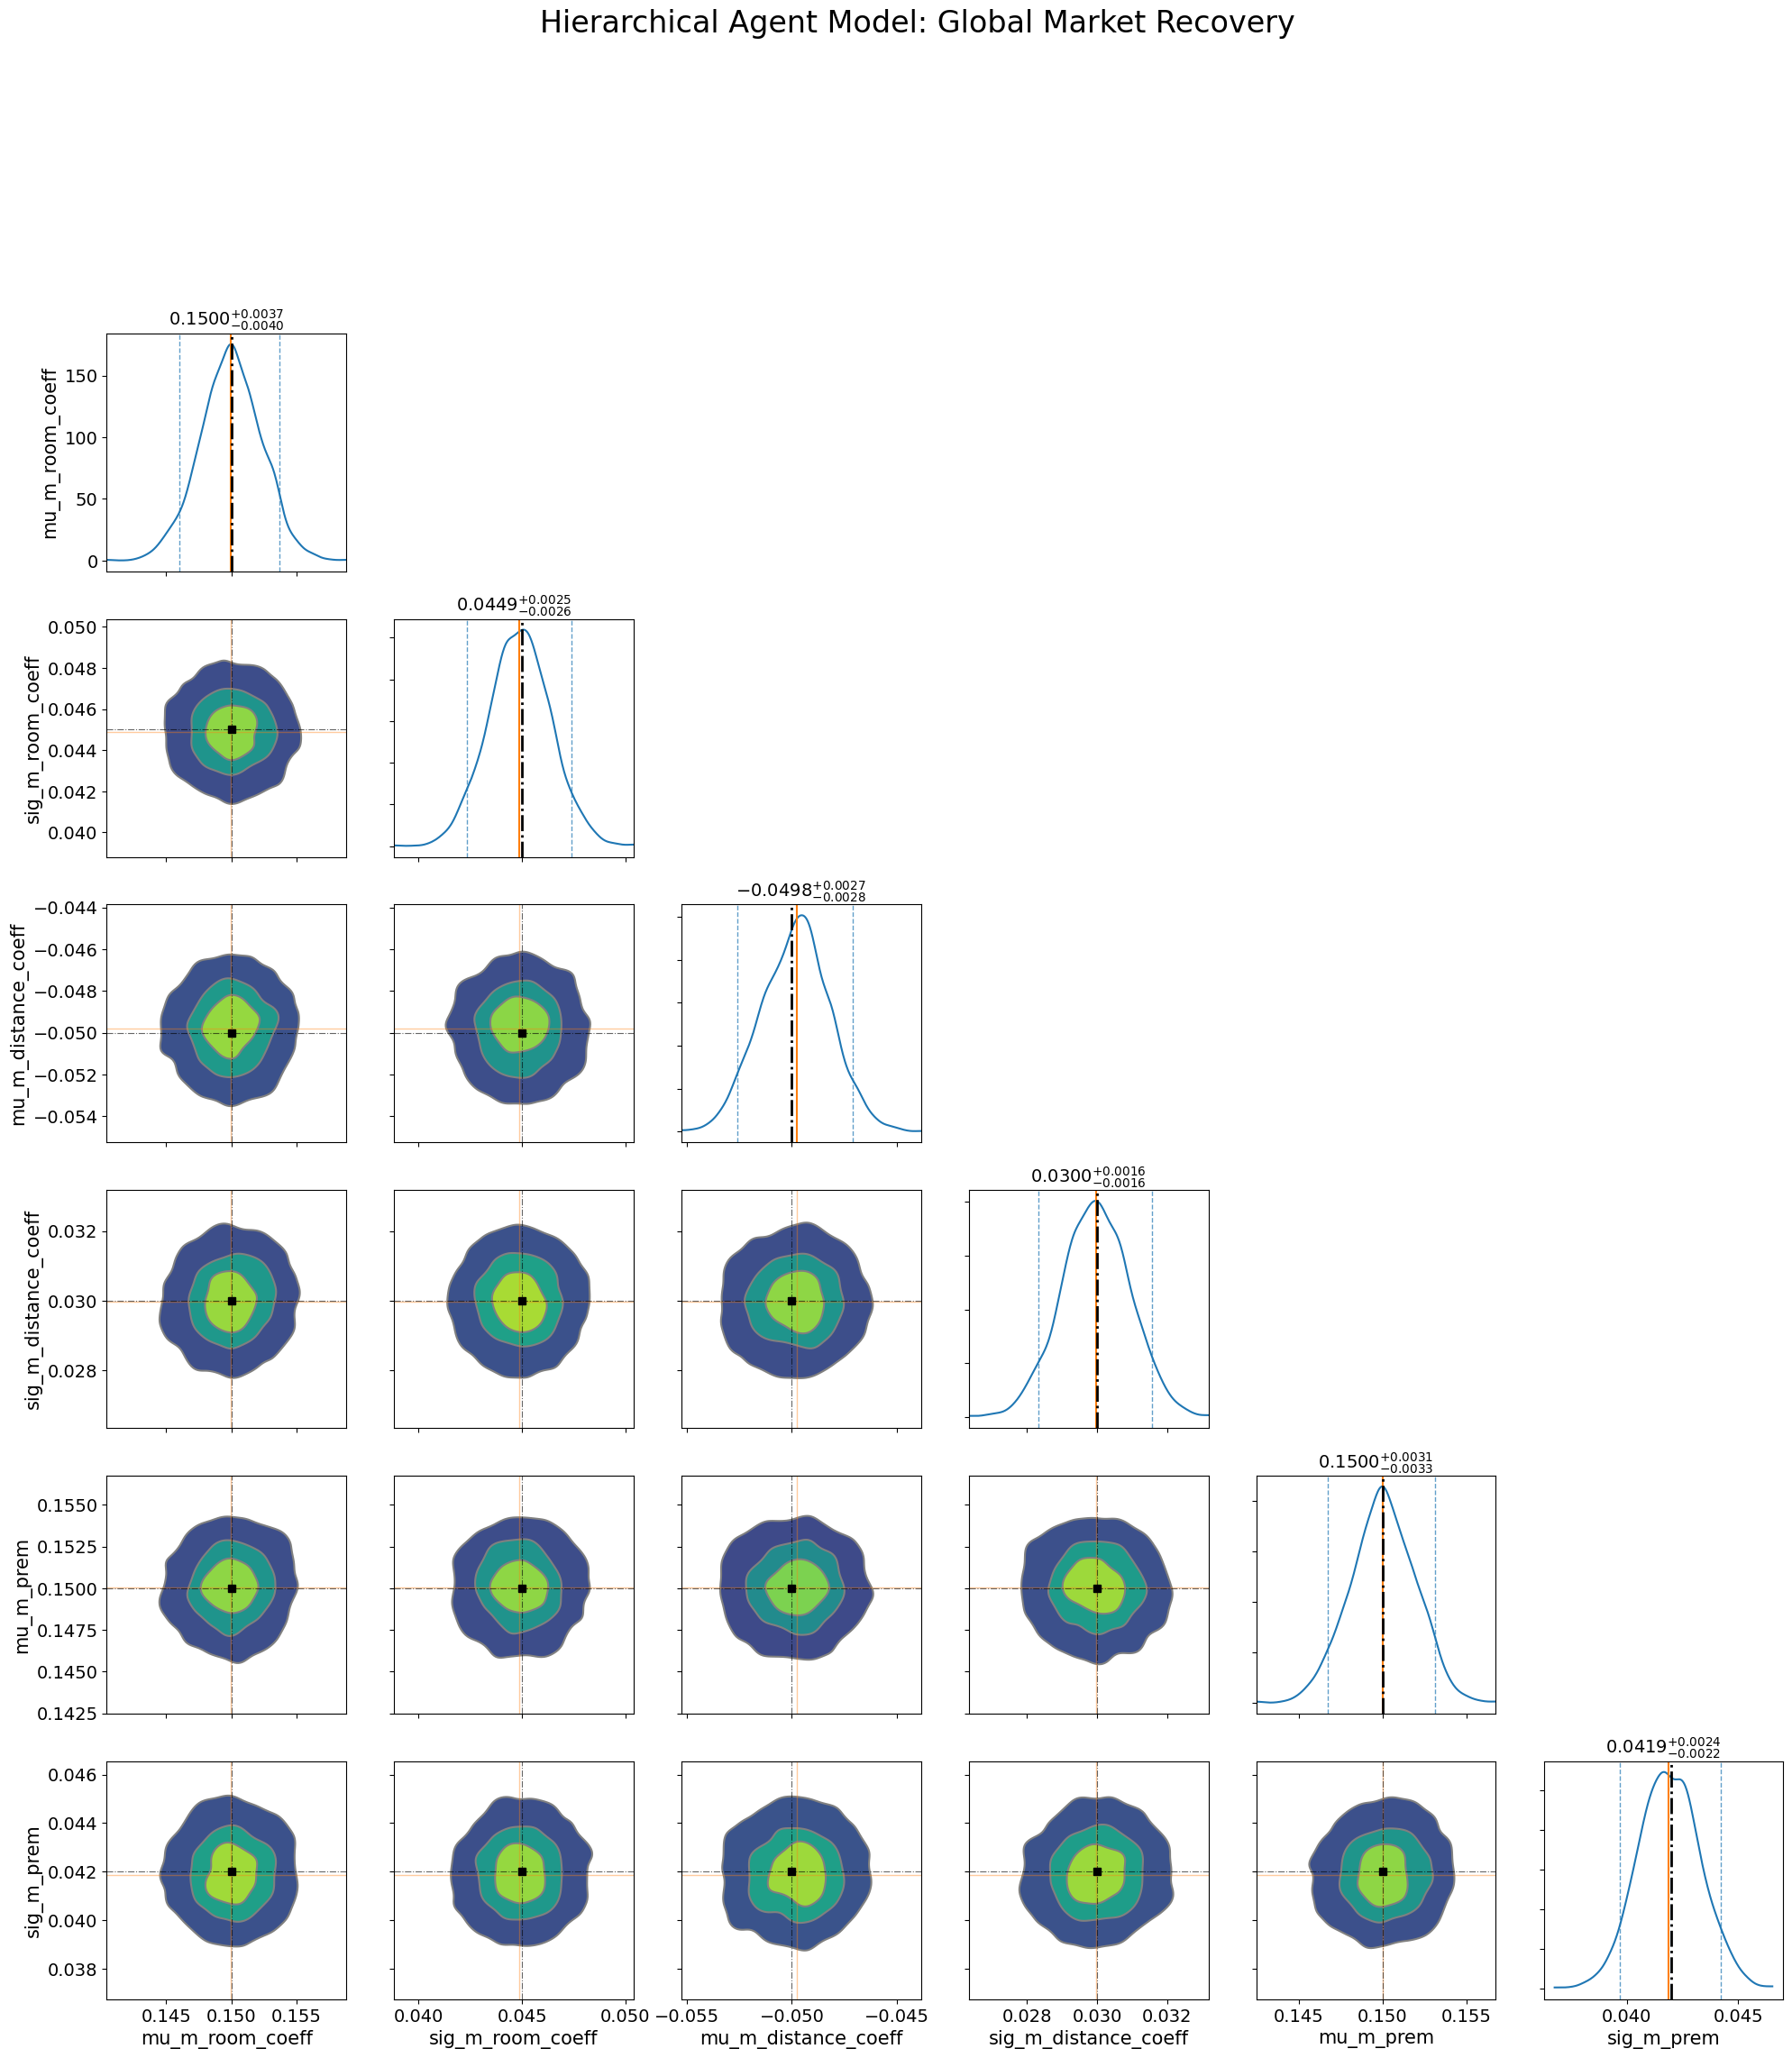

In [39]:
### Make corner plot of global parameters

# --- PLOTTING ---
axes = az.plot_pair(
    fin_tr_agent,
    var_names=all_plot_vars,
    kind='kde',
    marginals=True,
    figsize=(24, 24),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

all_x_labels = [ax.get_xlabel() for ax in axes[-1, :]]
all_y_labels = [ax.get_ylabel() for ax in axes[:, 0]]

for i in range(len(all_y_labels)):
    for j in range(len(all_x_labels)):
        ax = axes[i, j]
        if ax is None: continue
        
        row_label = all_y_labels[i]
        col_label = all_x_labels[j]

        def get_data(label):
            return fin_tr_agent.posterior[label].values.flatten()

        data_col = get_data(col_label)
        q5_c, med_c, q95_c = np.percentile(data_col, [5, 50, 95])

        if i == j:
            # --- 1D STATS (Orange Median + Blue Quantiles) ---
            ax.axvline(q5_c, color='C0', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(q95_c, color='C0', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(med_c, color='C1', linestyle='-', linewidth=1.5)
            
            # Add Truth Line (Black Dash-Dot)
            if col_label in market_parameters_truth:
                ax.axvline(market_parameters_truth[col_label], color='black', linestyle='-.', linewidth=2)
            
            # Set Title with Median and Error
            upper, lower = q95_c - med_c, med_c - q5_c
            ax.set_title(f"${med_c:.4f}^{{+{upper:.4f}}}_{{-{lower:.4f}}}$", fontsize=14)

        elif i > j:
            # --- 2D STATS (Orange Median Crosshair + Black Truth Square) ---
            data_row = get_data(row_label)
            med_r = np.median(data_row)
            
            # Orange Median lines
            ax.axvline(med_c, color='C1', linestyle='-', linewidth=1, alpha=0.4)
            ax.axhline(med_r, color='C1', linestyle='-', linewidth=1, alpha=0.4)
            
            # --- TRUTH CROSSHAIRS ---
            if row_label in market_parameters_truth and col_label in market_parameters_truth:
                # Vertical truth line
                ax.axvline(market_parameters_truth[col_label], color='black', linestyle='-.', linewidth=0.8, alpha=0.6)
                # Horizontal truth line
                ax.axhline(market_parameters_truth[row_label], color='black', linestyle='-.', linewidth=0.8, alpha=0.6)
                # Truth Square
                ax.plot(market_parameters_truth[col_label], market_parameters_truth[row_label], 
                        marker='s', color='black', markersize=6, zorder=15)

plt.suptitle("Hierarchical Agent Model: Global Market Recovery", fontsize=24, y=1.03)
plt.savefig(PLOT_DIR / "Corner Plot (Agent Model).png")
plt.show()

In [40]:
print("OWNER MODEL SUMMARY (Plot Variables Only)")
print("-" * 40)

# We use the same plot_vars and coords defined for the corner plot
stats_owner = az.summary(
    fin_tr_owner, 
    var_names=all_plot_vars[:-2], 
    round_to=3
)

print(stats_owner)

OWNER MODEL SUMMARY (Plot Variables Only)
----------------------------------------
                       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_m_room_coeff       0.150  0.002   0.146    0.155        0.0      0.0   
sig_m_room_coeff      0.045  0.002   0.042    0.048        0.0      0.0   
mu_m_distance_coeff  -0.050  0.002  -0.052   -0.047        0.0      0.0   
sig_m_distance_coeff  0.030  0.001   0.028    0.032        0.0      0.0   

                      ess_bulk  ess_tail  r_hat  
mu_m_room_coeff       3984.803  3817.996  1.000  
sig_m_room_coeff      3730.012  3811.033  1.001  
mu_m_distance_coeff   4028.974  3832.178  1.000  
sig_m_distance_coeff  3513.425  3899.466  1.000  


In [41]:
print("AGENT MODEL SUMMARY (Plot Variables Only)")
print("-" * 40)

# We use the same plot_vars and coords defined for the corner plot
stats_agent = az.summary(
    fin_tr_agent, 
    var_names=all_plot_vars, 
    round_to=3
)

print(stats_agent)

AGENT MODEL SUMMARY (Plot Variables Only)
----------------------------------------
                       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_m_room_coeff       0.150  0.002   0.145    0.154        0.0      0.0   
sig_m_room_coeff      0.045  0.002   0.042    0.048        0.0      0.0   
mu_m_distance_coeff  -0.050  0.002  -0.053   -0.047        0.0      0.0   
sig_m_distance_coeff  0.030  0.001   0.028    0.032        0.0      0.0   
mu_m_prem             0.150  0.002   0.146    0.153        0.0      0.0   
sig_m_prem            0.042  0.001   0.039    0.044        0.0      0.0   

                      ess_bulk  ess_tail  r_hat  
mu_m_room_coeff       4231.957  3879.240  1.000  
sig_m_room_coeff      3954.632  3671.587  1.001  
mu_m_distance_coeff   3779.380  3802.056  1.000  
sig_m_distance_coeff  3488.771  3752.061  1.002  
mu_m_prem             3953.884  3796.495  1.003  
sig_m_prem            3643.835  3890.282  1.001  


In [55]:
def compute_two_tailed_p_val(samples, truth):
    """
    Calculates the two-tailed Bayesian p-value.
    Defined as 2 * min(Pr(theta > truth), Pr(theta < truth)).
    """
    prob_greater = np.mean(samples > truth)
    prob_less = np.mean(samples < truth)
    # Handle edge cases where p-value could exceed 1.0 due to symmetry
    return 2 * min(prob_greater, prob_less)

hier_results_owner = []

# 2. Compute Z-Scores
for all_plot_var in all_plot_vars[:-2]:    
    # Scalar parameter
    post_samples = fin_tr_owner.posterior[all_plot_var].values.flatten()
    
    post_median = np.median(post_samples)
    post_sd = np.std(post_samples)
    injected_truth = market_parameters_truth[all_plot_var]
    
    z_score = (post_median - injected_truth) / post_sd
    
    p_val = compute_two_tailed_p_val(post_samples, injected_truth)

    hier_results_owner.append({
        "Model": "Owner",
        "Parameter": all_plot_var,
        "Injected Truth": injected_truth,
        "Posterior Median": post_median,
        "Posterior SD": post_sd,
        "Z-Score": z_score,
        "Two-Tailed p-value": p_val,
        "Recovery Status": "Success" if p_val >= 0.05 else "Shrinkage Warning"
    })

# 3. Display Results
z_score_hier_df_owner = pd.DataFrame(hier_results_owner)

print("Hierarchical Recovery Analysis - OWNER: Market Stats")
display(z_score_hier_df_owner.style.format({
    "Injected Truth": "{:.4f}",
    "Posterior Median": "{:.4f}",
    "Posterior SD": "{:.4f}",
    "Z-Score": "{:.3f}",
    "Two-Tailed p-value": "{:.3f}"
})
.background_gradient(subset=['Z-Score'], cmap='RdYlGn_r', vmin=-3, vmax=3)
.background_gradient(subset=['Two-Tailed p-value'], cmap='RdYlGn', vmin=0, vmax=1)
)

hier_results_agent = []

# 2. Compute Z-Scores
for all_plot_var in all_plot_vars:    
    # Scalar parameter
    post_samples = fin_tr_agent.posterior[all_plot_var].values.flatten()
    
    post_median = np.median(post_samples)
    post_sd = np.std(post_samples)
    injected_truth = market_parameters_truth[all_plot_var]
    
    z_score = (post_median - injected_truth) / post_sd
    
    p_val = compute_two_tailed_p_val(post_samples, injected_truth)

    hier_results_agent.append({
        "Model": "Agent",
        "Parameter": all_plot_var,
        "Injected Truth": injected_truth,
        "Posterior Median": post_median,
        "Posterior SD": post_sd,
        "Z-Score": z_score,
        "Two-Tailed p-value": p_val,
        "Recovery Status": "Success" if p_val >= 0.05 else "Shrinkage Warning"
    })

# 3. Display Results
z_score_hier_df_agent = pd.DataFrame(hier_results_agent)

print("\nHierarchical Recovery Analysis - AGENT: Market Stats")
display(z_score_hier_df_agent.style.format({
    "Injected Truth": "{:.4f}",
    "Posterior Median": "{:.4f}",
    "Posterior SD": "{:.4f}",
    "Z-Score": "{:.3f}",
    "Two-Tailed p-value": "{:.3f}"
})
.background_gradient(subset=['Z-Score'], cmap='RdYlGn_r', vmin=-3, vmax=3)
.background_gradient(subset=['Two-Tailed p-value'], cmap='RdYlGn', vmin=0, vmax=1)
)

print("\nZ-Score Interpretation Guide:")
print(f"{'-'*30}")
print("- |Z| < 1.0: Strong Recovery.") 
print("- 1.0 < |Z| < 2.0: Normal Tension.")
print("- |Z| > 2.0: Significant Shrinkage or Outlier.")
print("\nHierarchical Deep-Dive:")
print("- p-value > 0.05: Truth is statistically plausible.")
print("- p-value < 0.05: Truth is an outlier relative to the posterior (likely due to heavy Shrinkage).")

Hierarchical Recovery Analysis - OWNER: Market Stats


,Model,Parameter,Injected Truth,Posterior Median,Posterior SD,Z-Score,Two-Tailed p-value,Recovery Status
0,Owner,mu_m_room_coeff,0.1500,0.1505,0.0023,0.204,0.833,Success
1,Owner,sig_m_room_coeff,0.0450,0.0450,0.0015,-0.033,0.974,Success
2,Owner,mu_m_distance_coeff,-0.0500,-0.0497,0.0016,0.213,0.839,Success
3,Owner,sig_m_distance_coeff,0.0300,0.0301,0.0010,0.063,0.951,Success



Hierarchical Recovery Analysis - AGENT: Market Stats


,Model,Parameter,Injected Truth,Posterior Median,Posterior SD,Z-Score,Two-Tailed p-value,Recovery Status
0,Agent,mu_m_room_coeff,0.1500,0.1500,0.0024,-0.009,0.991,Success
1,Agent,sig_m_room_coeff,0.0450,0.0449,0.0015,-0.076,0.934,Success
2,Agent,mu_m_distance_coeff,-0.0500,-0.0498,0.0016,0.133,0.888,Success
3,Agent,sig_m_distance_coeff,0.0300,0.0300,0.0010,-0.036,0.973,Success
4,Agent,mu_m_prem,0.1500,0.1500,0.0019,0.016,0.983,Success
5,Agent,sig_m_prem,0.0420,0.0419,0.0014,-0.090,0.937,Success



Z-Score Interpretation Guide:
------------------------------
- |Z| < 1.0: Strong Recovery.
- 1.0 < |Z| < 2.0: Normal Tension.
- |Z| > 2.0: Significant Shrinkage or Outlier.

Hierarchical Deep-Dive:
- p-value > 0.05: Truth is statistically plausible.
- p-value < 0.05: Truth is an outlier relative to the posterior (likely due to heavy Shrinkage).


In [44]:
test_batch_agent = pd.read_csv(RESULTS_DIR / "test_batch_agent.csv")
test_batch_owner = pd.read_csv(RESULTS_DIR / "test_batch_owner.csv")

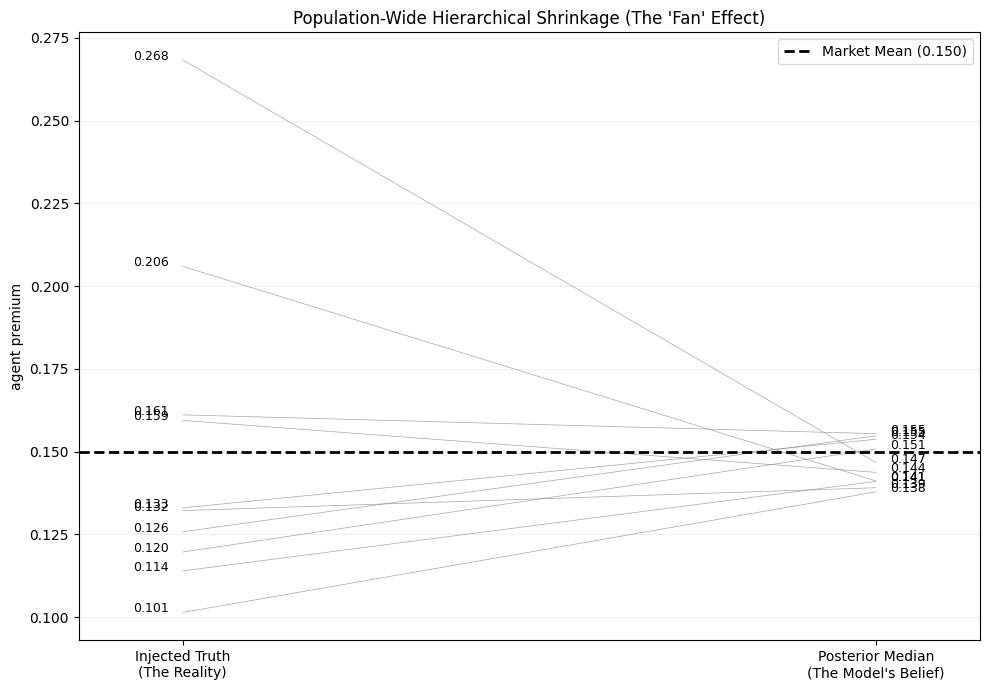

In [ ]:
prem_all_prop_truth_agent = test_batch_agent['premium'].values

p_premium_agent_post = fin_tr_agent.posterior["p_premium"].median(dim=["chain", "draw"]).values

plt.figure(figsize=(10, 7))

for i in range(len(prem_all_prop_truth_agent)):
    truth_val = prem_all_prop_truth_agent[i]
    recovered_val = p_premium_agent_post[i]
    
    plt.plot([0, 1], [truth_val, recovered_val], color='grey', alpha=0.7, linewidth=0.5)
    
    # Add text labels for the specific values to make it clear
    plt.text(-0.02, truth_val, f"{truth_val:.3f}", ha='right', fontsize=9)
    plt.text(1.02, recovered_val, f"{recovered_val:.3f}", ha='left', fontsize=9)

# 5. Add the Market Mean Anchor
plt.axhline(market_parameters_truth['mu_m_prem'], color='black', linestyle='--', linewidth=2, label=f"Market Mean ({market_parameters_truth['mu_m_prem']:.3f})")

# 6. Formatting the "Fan"
plt.xticks([0, 1], ["Injected Truth\n(The Reality)", "Posterior Median\n(The Model's Belief)"])
plt.ylabel("agent premium")
plt.title("Population-Wide Hierarchical Shrinkage (The 'Fan' Effect)")
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))

# Expand limits slightly for text labels
plt.xlim(-0.15, 1.15)
plt.tight_layout()
plt.savefig(PLOT_DIR / "Injection-Posterior Shrinkage (Agent Premium)")
plt.show()

In [47]:
analysed_params_owner = config['known_market_price_args'] + config['unknown_price_args']
analysed_params_agent = config['known_market_price_args'] + config['unknown_price_args'] + ['premium']

Computing Cook's Posterior Rank Transform across active properties...


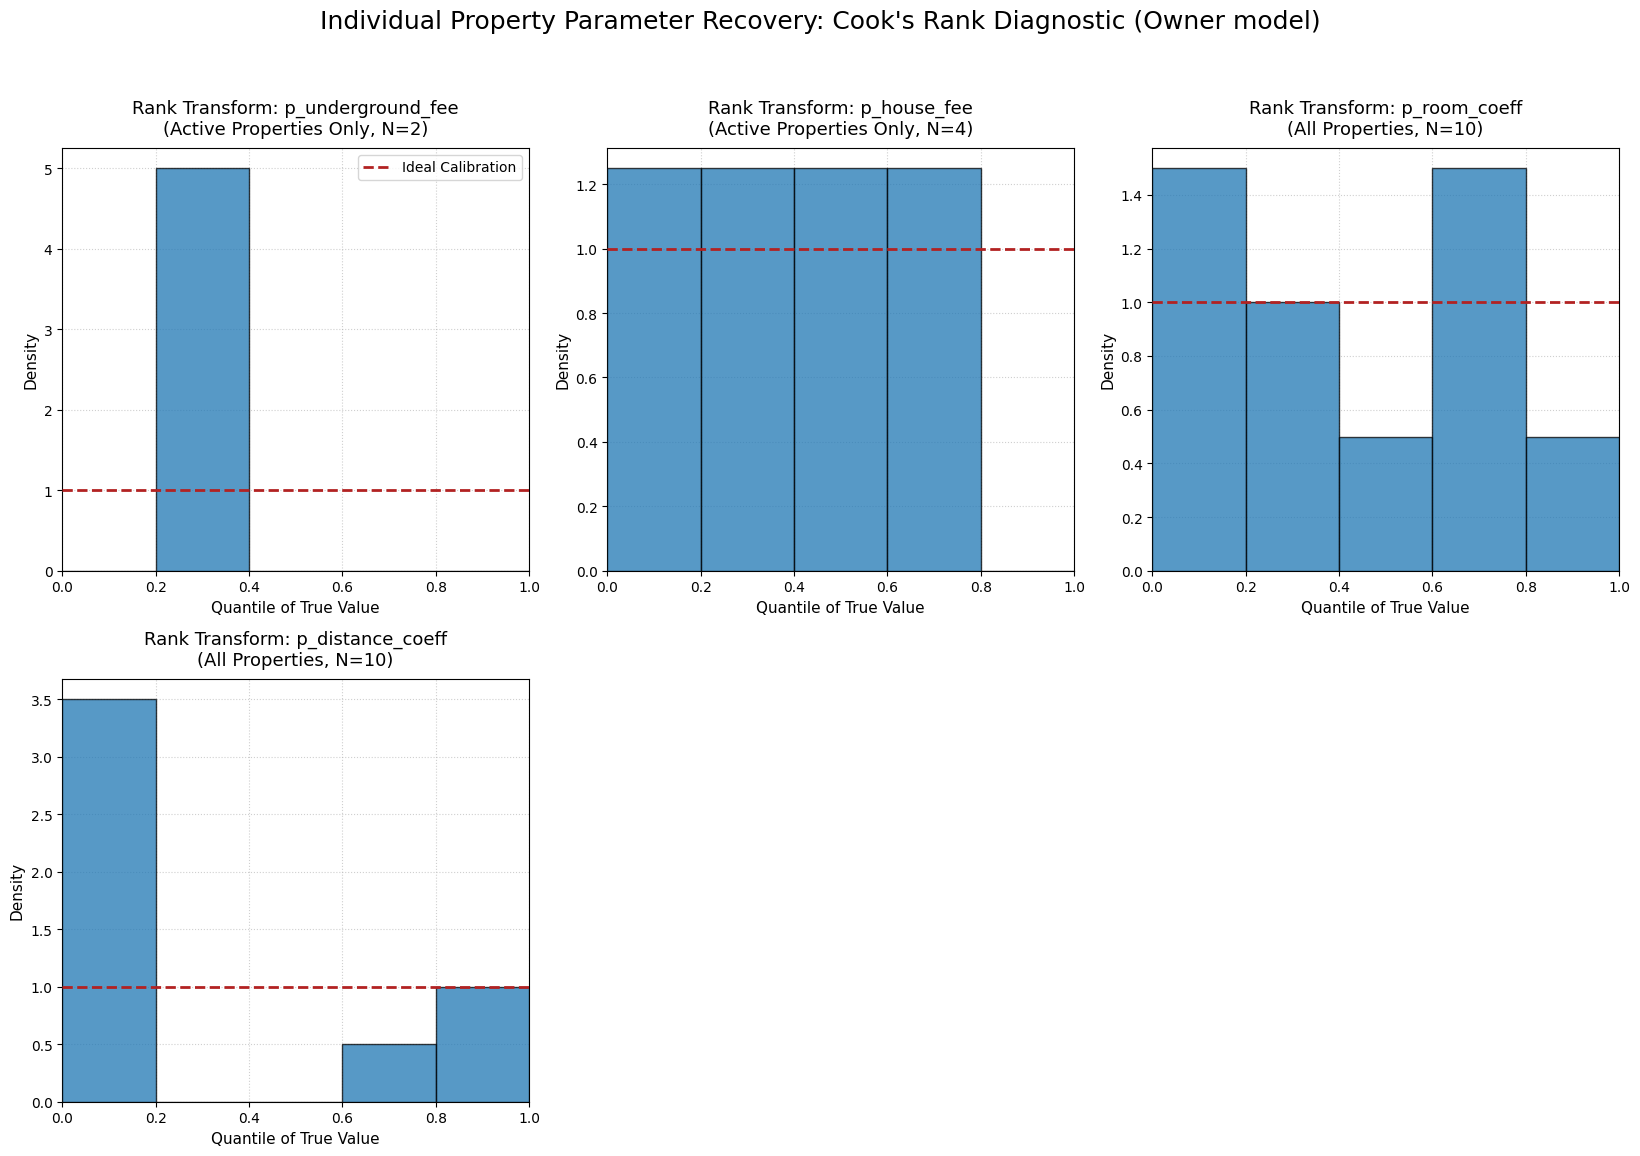

In [ ]:
# Define the property-level variables to check
prop_analysed_params_owner = [f"p_{param}" for param in analysed_params_owner]
num_plots = len(prop_analysed_params_owner)

# --- DYNAMIC GRID CALCULATION ---
ncols = 3  # Choose how many columns you want per row
nrows = (num_plots + ncols - 1) // ncols  # Computes rows needed (handles leftovers perfectly)

# Dynamically scale figsize: 5.5 inches per column width, 6 inches per row height
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.5 * ncols, 6 * nrows))

# Safely handle axes shape (handles edge cases where nrows=1 or ncols=1)
if num_plots == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()
# ---------------------------------

param_to_column_map = {
    "p_room_coeff": "beta_room",
    "p_distance_coeff": "beta_dist",
    "p_underground_fee": "beta_under",
    "p_house_fee": "beta_prop"
}

for idx, var_name in enumerate(prop_analysed_params_owner):
    ax = axes[idx]
    
    # Extract posterior samples. Shape: (chains, draws, num_properties)
    post_samples = fin_tr_owner.posterior[var_name].values
    num_properties = post_samples.shape[-1]
    
    # Collapse chains and draws into a single dimension: (total_samples, num_properties)
    flattened_samples = post_samples.reshape(-1, num_properties)
    
    # Retrieve the 1D ground-truth array corresponding to this parameter type
    csv_column_name = param_to_column_map[var_name]
    truths = test_batch_owner[csv_column_name].values
    
    # Compute the percentile rank of the truth within the posterior for each property
    property_ranks = []
    for k in range(num_properties):
        truth_val = truths[k]
        
        # Calculate what fraction of MCMC samples are strictly less than the injected truth
        rank = np.mean(flattened_samples[:, k] < truth_val)
        property_ranks.append((truth_val, rank))
    
    # --- DYNAMIC FILTERING FOR CONDITIONAL FEES ---
    if var_name in ["p_underground_fee", "p_house_fee", "p_garden_fee", "p_terrace_fee", "p_balcony_fee"]:
        # Only keep ranks where the ground truth is strictly greater than 0
        filtered_ranks = [rank for truth, rank in property_ranks if truth > 0.0]
        title_suffix = f"\n(Active Properties Only, N={len(filtered_ranks)})"
    else:
        filtered_ranks = [rank for truth, rank in property_ranks]
        title_suffix = f"\n(All Properties, N={len(filtered_ranks)})"
    # -----------------------------------------------
        
    # 3. Plot the rank distribution histogram with lower bin count (5 bins for N <= 20)
    if len(filtered_ranks) > 0:
        ax.hist(
            filtered_ranks, 
            bins=5, 
            range=(0, 1), 
            density=True, 
            alpha=0.75, 
            color='C0', 
            edgecolor='black', 
            zorder=3
        )
    else:
        # Visual fallback text if a batch happens to have zero eligible properties
        ax.text(0.5, 0.5, "No Active Properties\nin this batch", 
                ha='center', va='center', fontsize=12, color='gray')
    
    # Draw a reference line representing ideal uniform calibration
    ax.axhline(1.0, color='firebrick', linestyle='--', linewidth=2, label='Ideal Calibration', zorder=4)
    
    # Formatting adjustments
    ax.set_title(f"Rank Transform: {var_name}{title_suffix}", fontsize=13, pad=10)
    ax.set_xlabel("Quantile of True Value", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    if idx == 0:
        ax.legend(loc='upper right')

# --- DYNAMICALLY HIDE ALL EXTRA UNUSED SUBPLOTS ---
# Loops through whatever empty spaces remain at the bottom of your grid matrix
for empty_idx in range(num_plots, len(axes)):
    fig.delaxes(axes[empty_idx])
# ---------------------------------------------------

# Final layout polish
plt.suptitle("Individual Property Parameter Recovery: Cook's Rank Diagnostic (Owner model)", fontsize=18, y=0.96)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(PLOT_DIR / "Posterior Rank Calibration Diagnostic (Owner model).png")
plt.show()

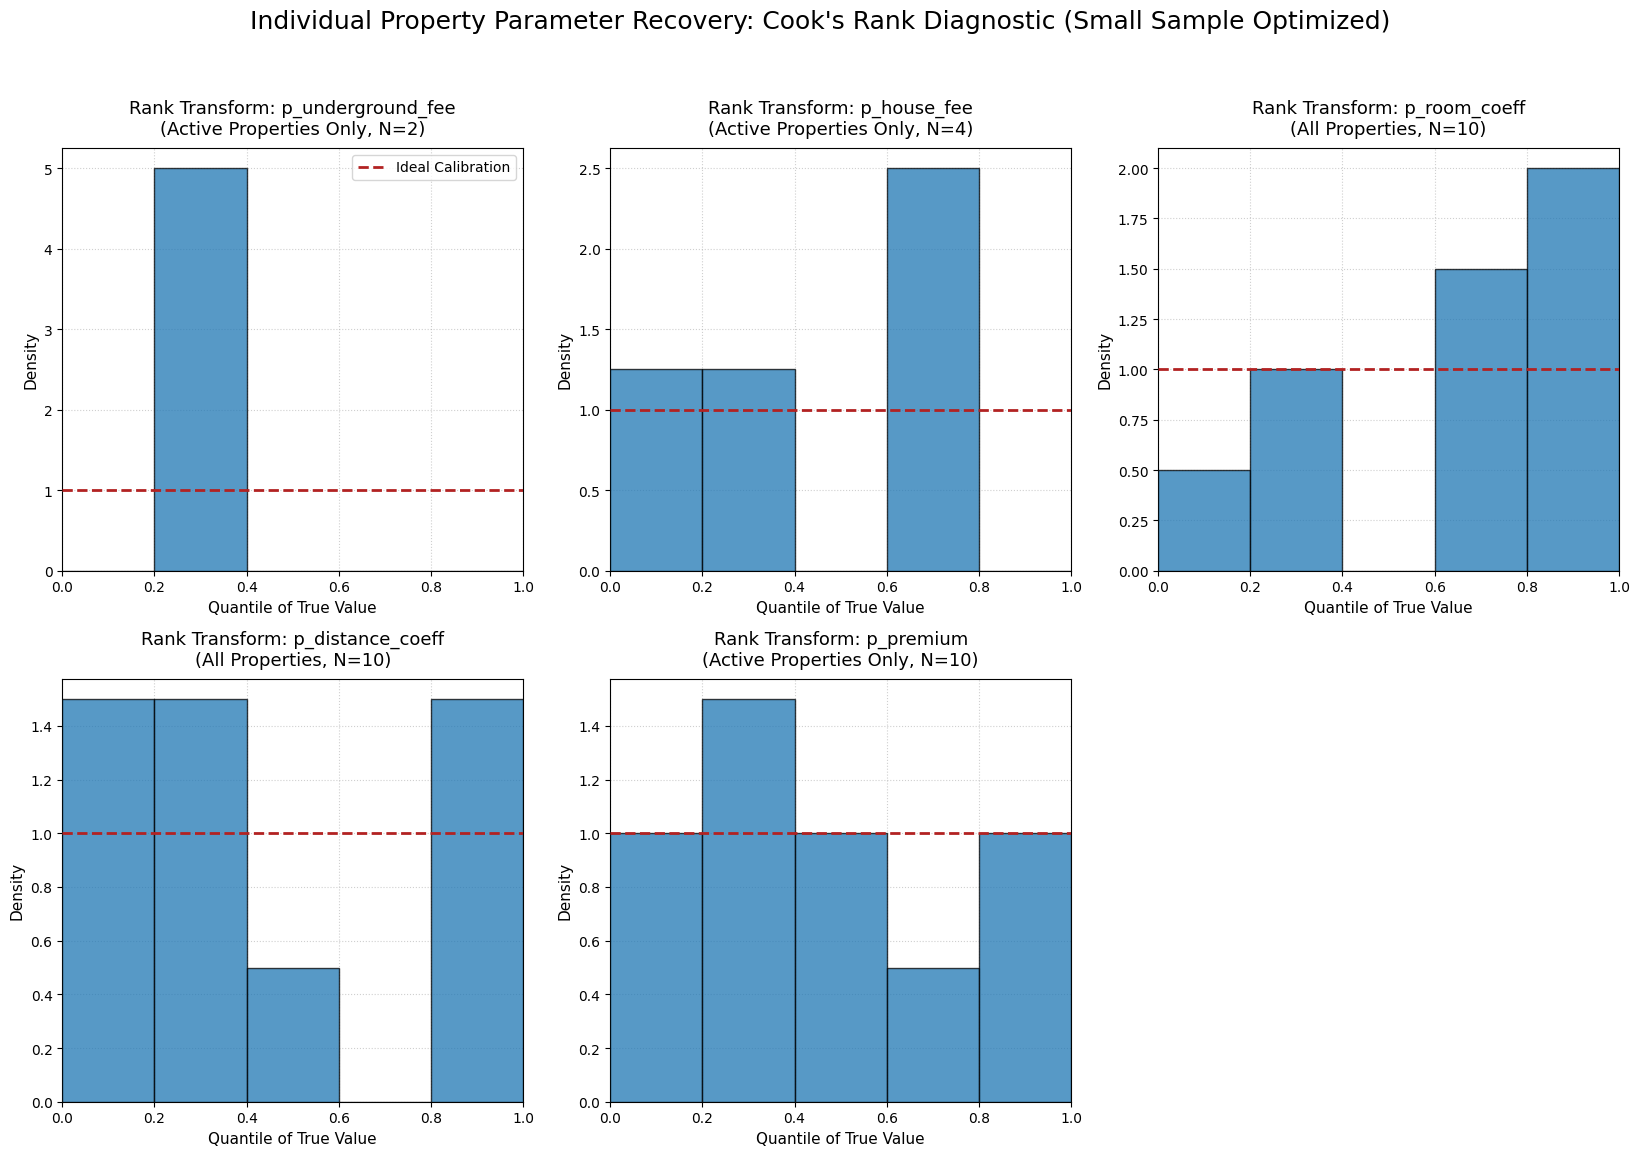

In [52]:
# Define the property-level variables to check
prop_analysed_params_agent = [f"p_{param}" for param in analysed_params_agent]
num_plots = len(prop_analysed_params_agent)

# --- DYNAMIC GRID CALCULATION ---
ncols = 3  # Choose how many columns you want per row
nrows = (num_plots + ncols - 1) // ncols  # Computes rows needed (handles leftovers perfectly)

# Dynamically scale figsize: 5.5 inches per column width, 6 inches per row height
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.5 * ncols, 6 * nrows))

# Safely handle axes shape (handles edge cases where nrows=1 or ncols=1)
if num_plots == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()
# ---------------------------------

param_to_column_map = {
    "p_room_coeff": "beta_room",
    "p_distance_coeff": "beta_dist",
    "p_underground_fee": "beta_under",
    "p_house_fee": "beta_prop",
    "p_premium": "premium"
}

for idx, var_name in enumerate(prop_analysed_params_agent):
    ax = axes[idx]
    
    # Extract posterior samples. Shape: (chains, draws, num_properties)
    post_samples = fin_tr_agent.posterior[var_name].values
    num_properties = post_samples.shape[-1]
    
    # Collapse chains and draws into a single dimension: (total_samples, num_properties)
    flattened_samples = post_samples.reshape(-1, num_properties)
    
    # Retrieve the 1D ground-truth array corresponding to this parameter type
    csv_column_name = param_to_column_map[var_name]
    truths = test_batch_agent[csv_column_name].values
    
    # Compute the percentile rank of the truth within the posterior for each property
    property_ranks = []
    for k in range(num_properties):
        truth_val = truths[k]
        
        # Calculate what fraction of MCMC samples are strictly less than the injected truth
        rank = np.mean(flattened_samples[:, k] < truth_val)
        property_ranks.append((truth_val, rank))
    
    # --- DYNAMIC FILTERING FOR CONDITIONAL FEES ---
    if var_name in ["p_underground_fee", "p_house_fee", "p_garden_fee", "p_terrace_fee", "p_balcony_fee", "p_premium"]:
        # Only keep ranks where the ground truth is strictly greater than 0
        filtered_ranks = [rank for truth, rank in property_ranks if truth > 0.0]
        title_suffix = f"\n(Active Properties Only, N={len(filtered_ranks)})"
    else:
        filtered_ranks = [rank for truth, rank in property_ranks]
        title_suffix = f"\n(All Properties, N={len(filtered_ranks)})"
    # -----------------------------------------------
        
    # 3. Plot the rank distribution histogram with lower bin count (5 bins for N <= 20)
    if len(filtered_ranks) > 0:
        ax.hist(
            filtered_ranks, 
            bins=5, 
            range=(0, 1), 
            density=True, 
            alpha=0.75, 
            color='C0', 
            edgecolor='black', 
            zorder=3
        )
    else:
        # Visual fallback text if a batch happens to have zero eligible properties
        ax.text(0.5, 0.5, "No Active Properties\nin this batch", 
                ha='center', va='center', fontsize=12, color='gray')
    
    # Draw a reference line representing ideal uniform calibration
    ax.axhline(1.0, color='firebrick', linestyle='--', linewidth=2, label='Ideal Calibration', zorder=4)
    
    # Formatting adjustments
    ax.set_title(f"Rank Transform: {var_name}{title_suffix}", fontsize=13, pad=10)
    ax.set_xlabel("Quantile of True Value", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    if idx == 0:
        ax.legend(loc='upper right')

# --- DYNAMICALLY HIDE ALL EXTRA UNUSED SUBPLOTS ---
# Loops through whatever empty spaces remain at the bottom of your grid matrix
for empty_idx in range(num_plots, len(axes)):
    fig.delaxes(axes[empty_idx])
# ---------------------------------------------------

# Final layout polish
plt.suptitle("Individual Property Parameter Recovery: Cook's Rank Diagnostic (Small Sample Optimized)", fontsize=18, y=0.96)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(PLOT_DIR / "Posterior Rank Calibration Diagnostic (Agent model).png")
plt.show()